In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "../weights_lora/Model/vlm_best_merged_model_PVD", torch_dtype="auto", device_map="auto"
)
# default processer
processor = AutoProcessor.from_pretrained("../weights_lora/Model/vlm_best_merged_model_PVD")



/home/mzhao/.conda/envs/Qwen_back/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]
The tokenizer you are loading from '../weights_lora/Model/vlm_best_merged_model_PVD' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


In [2]:
import hashlib
import math
import os
from decord import VideoReader, cpu
import numpy as np
from PIL import Image

def get_video_frames(video_path, num_frames=128, cache_dir='.cache'):
    os.makedirs(cache_dir, exist_ok=True)

    video_hash = hashlib.md5(video_path.encode('utf-8')).hexdigest()
    
    video_file_path = video_path

    frames_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_frames.npy')
    timestamps_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_timestamps.npy')

    if os.path.exists(frames_cache_file) and os.path.exists(timestamps_cache_file):
        frames = np.load(frames_cache_file)
        timestamps = np.load(timestamps_cache_file)
        return video_file_path, frames, timestamps

    vr = VideoReader(video_file_path, ctx=cpu(0))
    total_frames = len(vr)

    indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = vr.get_batch(indices).asnumpy()
    timestamps = np.array([vr.get_frame_timestamp(idx) for idx in indices])

    np.save(frames_cache_file, frames)
    np.save(timestamps_cache_file, timestamps)
    
    return video_file_path, frames, timestamps

def create_image_grid_adaptive(images, max_columns=8):
    """
    根据图片数量自动计算合适的列数
    - 少于8张：显示为1行
    - 多于8张：自动调整列数，让网格尽量方正
    """
    num_images = len(images)
    
    if num_images == 0:
        return None
    
    # 如果图片少于最大列数，直接显示为1行
    if num_images <= max_columns:
        num_columns = num_images
    else:
        # 计算合适的列数：让行数和列数尽量接近（正方形网格）
        num_columns = min(max_columns, math.ceil(math.sqrt(num_images * 1.5)))
        # 或者简单粗暴：直接用最大列数
        # num_columns = max_columns
    
    return create_image_grid(images, num_columns=num_columns)
def create_image_grid(images, num_columns=8):
    pil_images = [Image.fromarray(image) for image in images]
    num_rows = math.ceil(len(images) / num_columns)

    img_width, img_height = pil_images[0].size
    grid_width = num_columns * img_width
    grid_height = num_rows * img_height
    grid_image = Image.new('RGB', (grid_width, grid_height))

    for idx, image in enumerate(pil_images):
        row_idx = idx // num_columns
        col_idx = idx % num_columns
        position = (col_idx * img_width, row_idx * img_height)
        grid_image.paste(image, position)

    return grid_image

qwen-vl-utils using decord to read video.


['是']
64


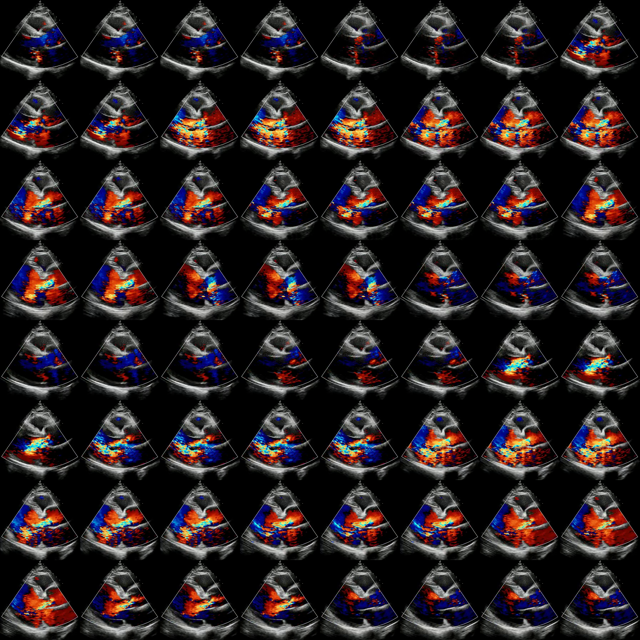

In [3]:
video_url="../Data/dicom_videos_group/Dataset/group_5/2024041804351700050569525e9/Doppler_Parasternal_Long.mp4"
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": video_url,
                "max_pixels": 224 * 224*3,
                "fps": 16.0,
            },
            {"type": "text", "text": "请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"},
        ],
    }
]

#In Qwen 2.5 VL, frame rate information is also input into the model to align with absolute time.
# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs, video_kwargs = process_vision_info(messages, return_video_kwargs=True)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    # fps=16,
    padding=True,
    return_tensors="pt",
    **video_kwargs,
)
inputs = inputs.to("cuda")

# Inference
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid_adaptive(frames, max_columns=8)
display(image_grid.resize((640, 640)))